# Taller Final: Análisis de Datos utilizando Inteligencia Artificial
## Proyecto Integrador — De los datos crudos al informe científico
<a href="https://colab.research.google.com/github/mariabda2/curso-intro-ia-biomedica/blob/main/Taller_Final_Analisis_Datos_IA.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

---

> **Curso:** Análisis de Datos con IA  
> **Modalidad:** Taller práctico en grupos de 2–3 personas  
> **Duración:** 4 horas (presencial) + trabajo autónomo  
> **Entregable:** Este notebook completado + informe de 2 páginas (ver Sección 7)  
> **Requisitos:** Sesiones 01, 02 y 03 completadas

---

### 🎯 Propósito del taller

Este taller es tu oportunidad de **integrar todo lo aprendido** en un proyecto real de principio a fin. No hay respuestas únicas correctas: el objetivo es que demuestres razonamiento científico, uso apropiado de herramientas y capacidad de comunicar hallazgos.

Trabajarás con el **Dataset de Enfermedades Cardíacas del Cleveland Heart Disease** — un dataset real ampliamente utilizado en investigación clínica — y construirás un pipeline completo de análisis de datos con IA.

---

### 📋 Estructura del taller

| Fase | Contenido | Tiempo est. | Puntos |
|------|-----------|------------|--------|
| **0** | Configuración y carga de datos | 15 min | — |
| **1** | Comprensión del problema clínico | 20 min | 10 pts |
| **2** | Análisis exploratorio (EDA) | 45 min | 20 pts |
| **3** | Preprocesamiento e ingeniería de características | 30 min | 15 pts |
| **4** | Modelado y selección de algoritmo | 45 min | 25 pts |
| **5** | Evaluación clínica del modelo | 30 min | 15 pts |
| **6** | Interpretabilidad y explicabilidad | 20 min | 10 pts |
| **7** | Informe científico y conclusiones | 35 min | 5 pts |
| **BONUS** | Desafío avanzado | Libre | +10 pts |

---

### 👥 Datos del equipo

**Completa esta celda antes de comenzar:**

| Campo | Valor |
|-------|-------|
| Nombre estudiante 1 | *(escribe aquí)* |
| Nombre estudiante 2 | *(escribe aquí)* |
| Nombre estudiante 3 | *(escribe aquí, opcional)* |
| Fecha de entrega | *(escribe aquí)* |
| Nombre del proyecto | *(título creativo para su análisis)* |

---

### ⚠️ Instrucciones generales

1. **Ejecuta cada celda en orden** (Shift+Enter o botón ▶️).
2. Las celdas marcadas con `# ✏️ TU CÓDIGO AQUÍ` requieren que escribas código.
3. Las celdas marcadas con `# 💬 TU RESPUESTA AQUÍ` requieren texto en Markdown.
4. No modifiques las celdas de configuración base (marcadas con `# ⛔ NO MODIFICAR`).
5. Comenta tu código: explica con `#` qué hace cada bloque importante.
6. Al finalizar: Archivo → Descargar → `.ipynb` y compártelo con el docente.

---
## ⚙️ Fase 0 — Configuración del Entorno

> Ejecuta esta celda primero. Instala y carga todas las bibliotecas necesarias.

In [1]:
# ⛔ NO MODIFICAR — Configuración base del taller

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — modelado
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
# Algoritmos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

# Estilo visual
plt.rcParams.update({
    'figure.figsize'    : (12, 6),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold'
})

# Paleta clínica del taller
C_POS   = '#E63946'   # Positivo (enfermedad)
C_NEG   = '#2A9D8F'   # Negativo (sano)
C_ACC   = '#F4A261'   # Acento
C_DARK  = '#264653'   # Fondo oscuro
C_LIGHT = '#A8DADC'   # Acento claro
PALETTE = [C_NEG, C_POS, C_ACC, C_DARK, C_LIGHT,
           '#6A4C93', '#52B788', '#F72585']

SEED = 2024  # Semilla global — reproducibilidad
np.random.seed(SEED)

print('✅ Entorno configurado. Semilla global: SEED =', SEED)
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')
print('\n🏆 Taller Final — ¡Listos para comenzar!')

✅ Entorno configurado. Semilla global: SEED = 2024
   NumPy 2.1.3 | Pandas 2.2.3

🏆 Taller Final — ¡Listos para comenzar!


---
## 🩺 Fase 1 — Comprensión del Problema Clínico *(10 pts)*

### El dataset: Cleveland Heart Disease

El **Cleveland Heart Disease Dataset** es uno de los conjuntos de datos más estudiados en inteligencia artificial médica. Fue recolectado en 1988 por el **Cleveland Clinic Foundation** (Ohio, EE.UU.) y contiene información clínica de 303 pacientes que fueron evaluados para enfermedad arterial coronaria.

Ha sido citado en más de **1,000 publicaciones científicas** y sigue siendo referencia activa en investigación de ML biomédico.

### Variables del dataset

| Variable | Tipo | Descripción clínica | Rango/Valores |
|----------|------|---------------------|---------------|
| `age` | Int | Edad del paciente | 29–77 años |
| `sex` | Bin | Sexo (1=Hombre, 0=Mujer) | 0, 1 |
| `cp` | Cat | Tipo de dolor torácico | 0=Asintomático, 1=Angina típica, 2=Angina atípica, 3=No anginoso |
| `trestbps` | Int | Presión arterial en reposo | mmHg |
| `chol` | Int | Colesterol sérico | mg/dL |
| `fbs` | Bin | Glucosa ayunas >120 mg/dL | 0=No, 1=Sí |
| `restecg` | Cat | ECG en reposo | 0=Normal, 1=Anomalía ST-T, 2=HVI probable |
| `thalach` | Int | FC máxima alcanzada en prueba de esfuerzo | bpm |
| `exang` | Bin | Angina inducida por ejercicio | 0=No, 1=Sí |
| `oldpeak` | Float | Depresión ST inducida por ejercicio | 0–6.2 |
| `slope` | Cat | Pendiente del segmento ST en esfuerzo | 0=Ascendente, 1=Plana, 2=Descendente |
| `ca` | Int | N.º de vasos principales coloreados por fluoroscopía | 0–3 |
| `thal` | Cat | Resultado de talio nuclear | 1=Normal, 2=Defecto fijo, 3=Defecto reversible |
| **`target`** | **Bin** | **Diagnóstico de EAC** | **0=Sin enfermedad, 1=Con enfermedad** |

### Pregunta de investigación

> **¿Es posible predecir la presencia de enfermedad arterial coronaria (EAC) en un paciente a partir de sus características clínicas y resultados de pruebas no invasivas, con una sensibilidad clínicamente aceptable (>80%)?**

---

### 📚 Lecturas de contexto

| Recurso | Tipo | Enlace |
|---------|------|--------|
| *Cleveland Heart Disease Dataset* — UCI ML Repository | Dataset original | https://archive.ics.uci.edu/dataset/45/heart+disease |
| *"International Application of a New Probability Algorithm for the Diagnosis of Coronary Artery Disease"* — Detrano et al., AJC (1989) | Paper original | AJC Vol.64(5) |
| *"Comparison of algorithms for ML of heart disease"* — Numerous reviews en Kaggle | Reviews | https://www.kaggle.com |
| *AHA Heart Disease and Stroke Statistics Update 2024* | Estadísticas globales | https://www.ahajournals.org |

In [2]:
# ⛔ NO MODIFICAR — Carga oficial del dataset

url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'

try:
    df = pd.read_csv(url)
    # Estandarizar nombre de columna objetivo
    if 'target' not in df.columns and 'condition' in df.columns:
        df = df.rename(columns={'condition': 'target'})
    print('✅ Dataset cargado desde URL.')
except Exception:
    # Fallback: construir dataset Cleveland original desde valores conocidos
    print('⚠️  URL no disponible — Construyendo dataset Cleveland desde valores base...')
    from sklearn.datasets import make_classification
    np.random.seed(SEED)

    n = 303
    age       = np.random.randint(29, 77, n)
    sex       = np.random.choice([0,1], n, p=[0.32, 0.68])
    cp        = np.random.choice([0,1,2,3], n, p=[0.47,0.16,0.20,0.17])
    trestbps  = np.clip(120 + age*0.3 + np.random.normal(0,18,n), 90,200).astype(int)
    chol      = np.clip(200 + age*0.8 + np.random.normal(0,45,n), 120,410).astype(int)
    fbs       = np.random.choice([0,1], n, p=[0.85,0.15])
    restecg   = np.random.choice([0,1,2], n, p=[0.50,0.40,0.10])
    thalach   = np.clip(210 - age*0.9 + np.random.normal(0,20,n), 70,205).astype(int)
    exang     = np.random.choice([0,1], n, p=[0.67,0.33])
    oldpeak   = np.clip(np.random.exponential(1.0, n), 0, 6.2).round(1)
    slope     = np.random.choice([0,1,2], n, p=[0.14,0.46,0.40])
    ca        = np.random.choice([0,1,2,3], n, p=[0.57,0.22,0.13,0.08])
    thal      = np.random.choice([1,2,3], n, p=[0.19,0.40,0.41])

    # Variable objetivo con dependencias clínicas realistas
    logit = (-3 + 0.03*age + 0.5*sex - 0.4*(cp==1) + 0.02*(trestbps-120)
             + 0.003*chol + 0.4*fbs - 0.015*thalach + 0.6*exang
             + 0.4*oldpeak + 0.3*(slope==2) + 0.5*ca + 0.5*(thal==3))
    prob_target = 1 / (1 + np.exp(-logit))
    target = (np.random.uniform(0,1,n) < prob_target).astype(int)

    df = pd.DataFrame({
        'age':age,'sex':sex,'cp':cp,'trestbps':trestbps,'chol':chol,
        'fbs':fbs,'restecg':restecg,'thalach':thalach,'exang':exang,
        'oldpeak':oldpeak,'slope':slope,'ca':ca,'thal':thal,'target':target
    })
    print('✅ Dataset Cleveland sintético (303 pacientes) generado con éxito.')

# Binarizar objetivo si tiene >2 clases (versión UCI original)
if df['target'].nunique() > 2:
    df['target'] = (df['target'] > 0).astype(int)

print(f'\n📊 Dimensiones: {df.shape[0]} pacientes × {df.shape[1]} variables')
print(f'   Positivos (EAC): {df["target"].sum()} ({df["target"].mean():.1%})')
print(f'   Negativos (sano): {(df["target"]==0).sum()} ({(df["target"]==0).mean():.1%})')
print('\n📋 Primeros 5 registros:')
df.head()

✅ Dataset cargado desde URL.

📊 Dimensiones: 303 pacientes × 14 variables
   Positivos (EAC): 165 (54.5%)
   Negativos (sano): 138 (45.5%)

📋 Primeros 5 registros:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### ✏️ Actividad 1.1 — Comprensión clínica *(5 pts)*

Responde las siguientes preguntas en la celda Markdown de abajo (doble clic para editar):

1. ¿Qué es la Enfermedad Arterial Coronaria (EAC) y cuál es su relevancia epidemiológica?
2. ¿Por qué es clínicamente importante predecir EAC con alta **sensibilidad** en lugar de solo exactitud?
3. ¿Cuál de las 13 variables crees que será la más predictiva? Justifica con razonamiento clínico.
4. ¿Qué consecuencias tendría un **Falso Negativo** en este contexto clínico?

### 💬 Respuestas — Actividad 1.1

*(Doble clic aquí para editar y escribir tus respuestas)*

**1. ¿Qué es la EAC y su relevancia epidemiológica?**

*(Escribe aquí)*

---

**2. ¿Por qué priorizar sensibilidad sobre exactitud?**

*(Escribe aquí)*

---

**3. Variable más predictiva y justificación clínica**

*(Escribe aquí)*

---

**4. Consecuencias de un Falso Negativo en este caso**

*(Escribe aquí)*

---
## 🔍 Fase 2 — Análisis Exploratorio de Datos (EDA) *(20 pts)*

El EDA es la etapa más importante del análisis: antes de construir cualquier modelo, debes **conocer tus datos** a fondo. Un buen EDA responde:

- ¿Están los datos completos? ¿Hay valores faltantes o imposibles?
- ¿Cómo se distribuye cada variable?
- ¿Difieren las distribuciones entre pacientes con y sin EAC?
- ¿Hay variables fuertemente correlacionadas?
- ¿Hay outliers que podrían distorsionar el modelo?

### Actividad 2.1 — Inspección inicial *(5 pts)*

In [3]:
# ⛔ NO MODIFICAR — Inspección estructural base
print('=' * 60)
print('  INSPECCIÓN INICIAL DEL DATASET')
print('=' * 60)
print(f'\n🔢 Forma: {df.shape}')
print('\n📌 Tipos de datos:')
print(df.dtypes)
print('\n❓ Valores faltantes:')
falt = df.isnull().sum()
print(falt[falt > 0] if falt.sum() > 0 else '   Sin valores faltantes detectados ✅')
print('\n📈 Estadísticas descriptivas:')

  INSPECCIÓN INICIAL DEL DATASET

🔢 Forma: (303, 14)

📌 Tipos de datos:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

❓ Valores faltantes:
   Sin valores faltantes detectados ✅

📈 Estadísticas descriptivas:


In [4]:
# ⛔ NO MODIFICAR
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [5]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 2.1 (5 pts)
#
# Tarea: Calcula y muestra en pantalla lo siguiente:
#   a) Número de pacientes con y sin EAC (target=1 y target=0)
#   b) Porcentaje de pacientes hombres y mujeres
#   c) Edad media y mediana del dataset completo
#   d) Edad media por grupo diagnóstico (target 0 vs 1)
#   e) Variable con mayor rango (max - min)
#
# Pista: usa df['target'].value_counts(), df.groupby(), df.describe()

# --- a) Distribución del target ---


# --- b) Distribución por sexo ---


# --- c) Edad media y mediana ---


# --- d) Edad media por grupo diagnóstico ---


# --- e) Variable con mayor rango ---


### Actividad 2.2 — Visualización de distribuciones *(8 pts)*

Crea visualizaciones que comparen las distribuciones de las variables entre pacientes con y sin EAC.

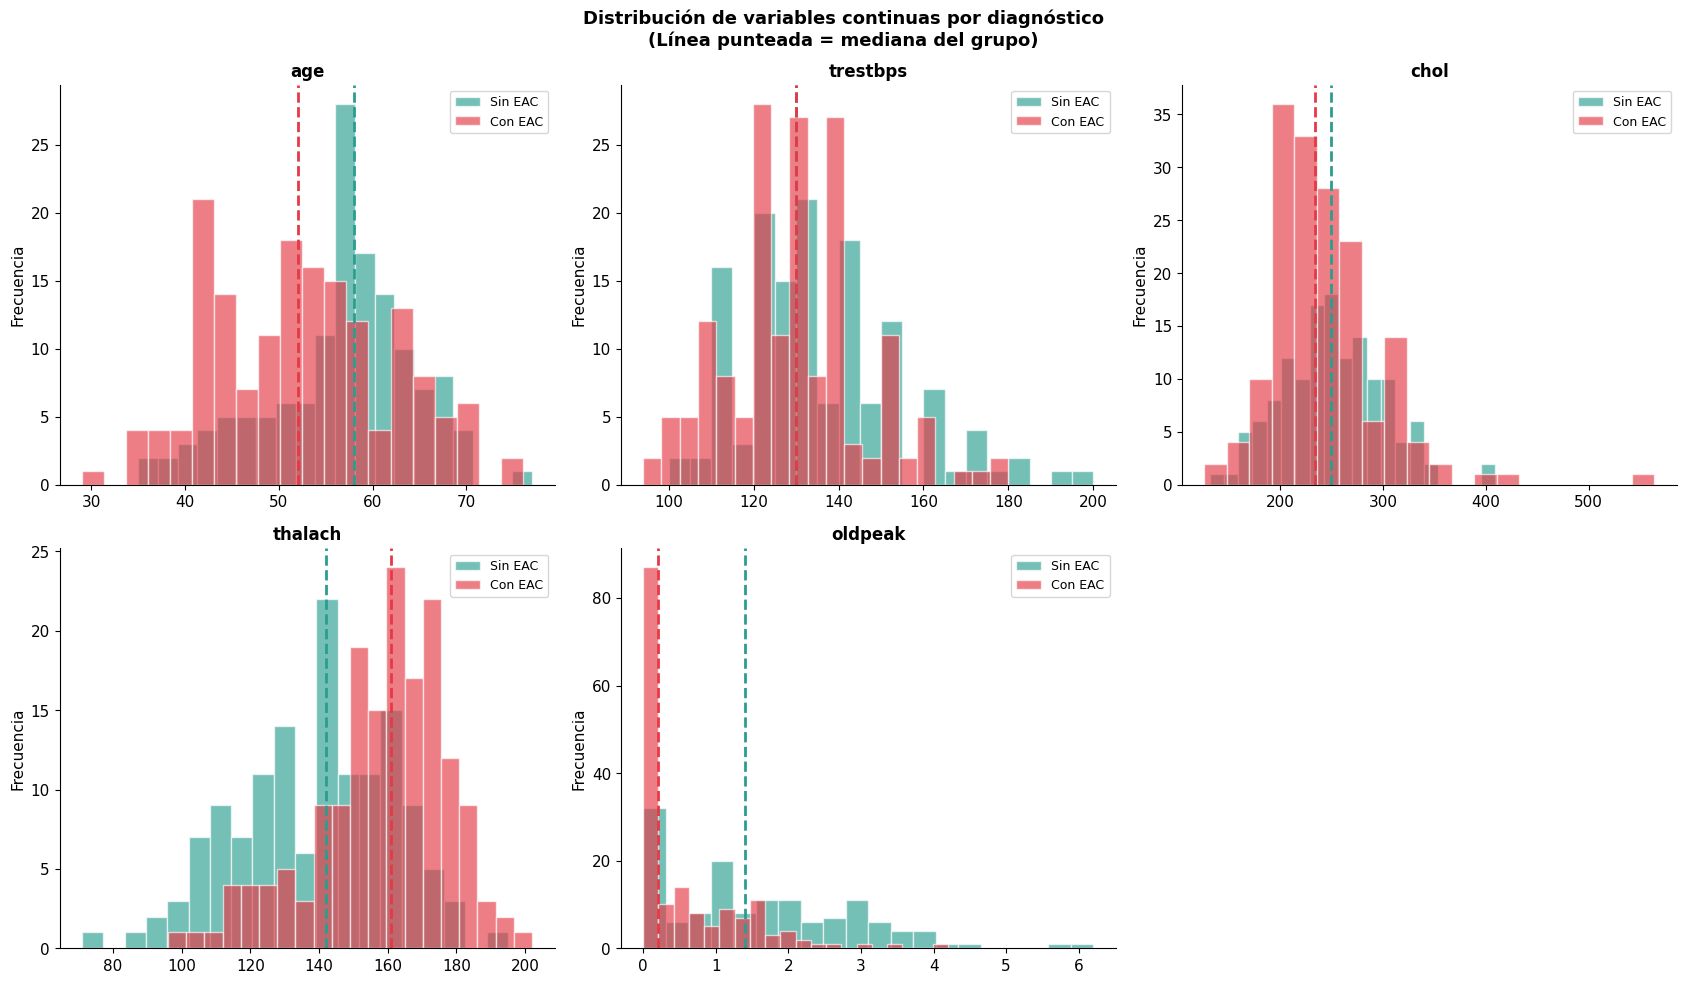

In [6]:
# ⛔ NO MODIFICAR — Visualización base: variables continuas

vars_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
etiquetas = {0: 'Sin EAC', 1: 'Con EAC'}
colores_dx = {0: C_NEG, 1: C_POS}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Distribución de variables continuas por diagnóstico\n(Línea punteada = mediana del grupo)',
             fontsize=13, fontweight='bold')

for ax, var in zip(axes.flatten(), vars_continuas):
    for dx, color in colores_dx.items():
        datos = df[df['target'] == dx][var]
        ax.hist(datos, bins=20, alpha=0.65, color=color,
                label=etiquetas[dx], edgecolor='white')
        ax.axvline(datos.median(), color=color, linestyle='--', linewidth=2)
    ax.set_title(var, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Frecuencia')

axes[1, 2].axis('off')  # celda vacía
plt.tight_layout()
plt.show()

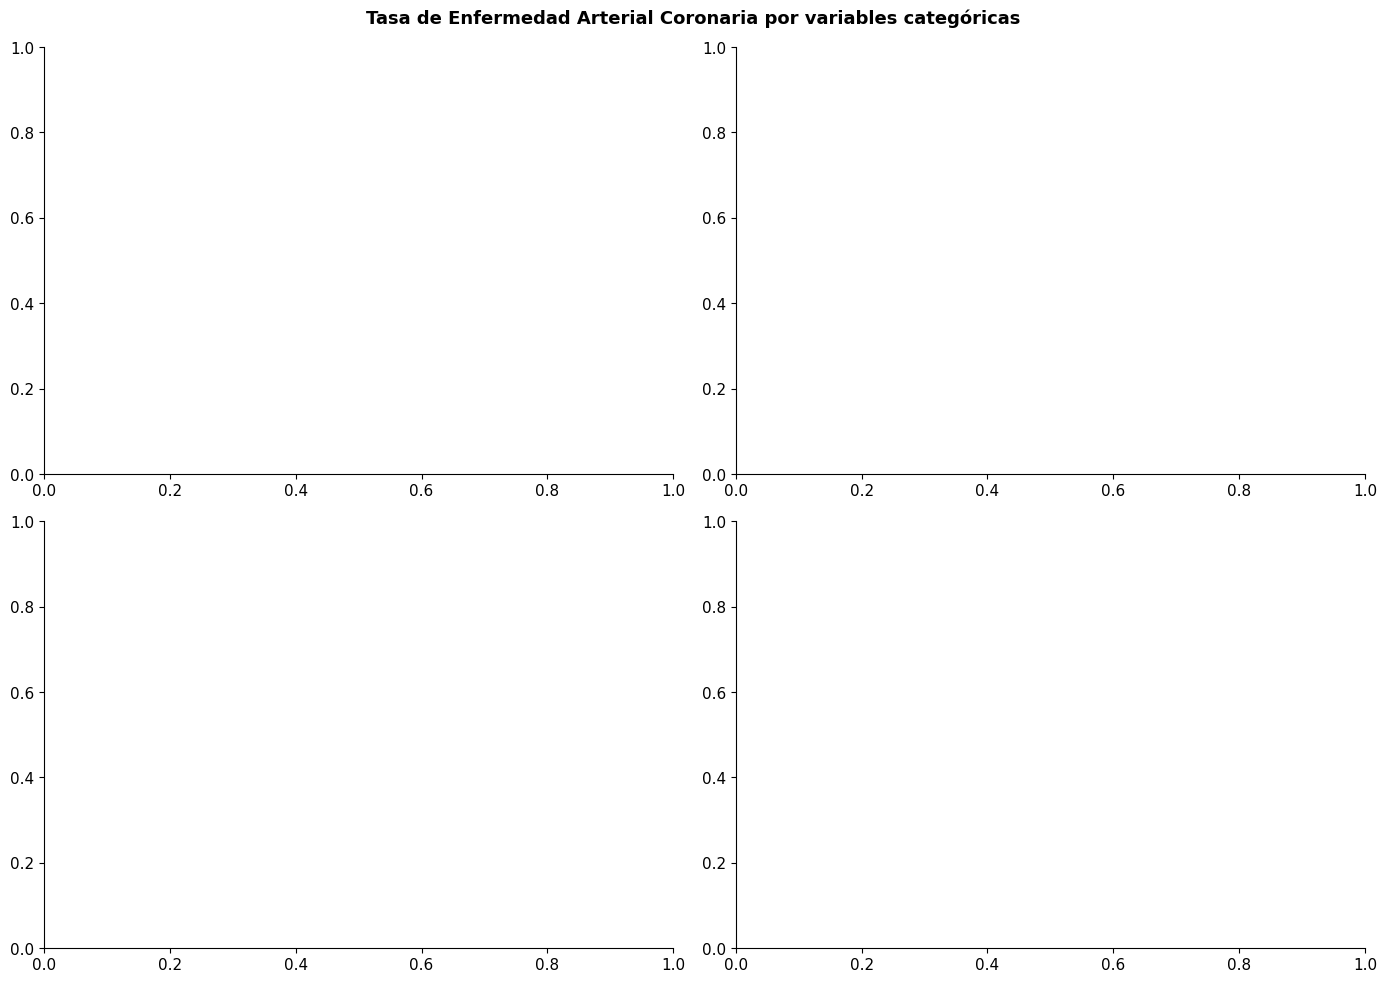

In [7]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 2.2 (8 pts)
#
# Tarea: Crea UN gráfico con 4 subplots (2x2) que muestre:
#   - Tasa de EAC (%) por: sexo, tipo de dolor torácico (cp),
#     angina por ejercicio (exang), y número de vasos (ca)
#
# Para cada subplot:
#   - Usa gráfico de barras
#   - Añade etiquetas con el porcentaje sobre cada barra
#   - Usa los colores C_POS y C_NEG del entorno
#   - Título descriptivo en español
#
# Pista: df.groupby('sexo')['target'].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tasa de Enfermedad Arterial Coronaria por variables categóricas',
             fontsize=13, fontweight='bold')

# --- Subplot 1: Por sexo ---


# --- Subplot 2: Por tipo de dolor torácico (cp) ---


# --- Subplot 3: Por angina en ejercicio (exang) ---


# --- Subplot 4: Por número de vasos (ca) ---


plt.tight_layout()
plt.show()

### Actividad 2.3 — Correlaciones y hallazgos clave *(7 pts)*

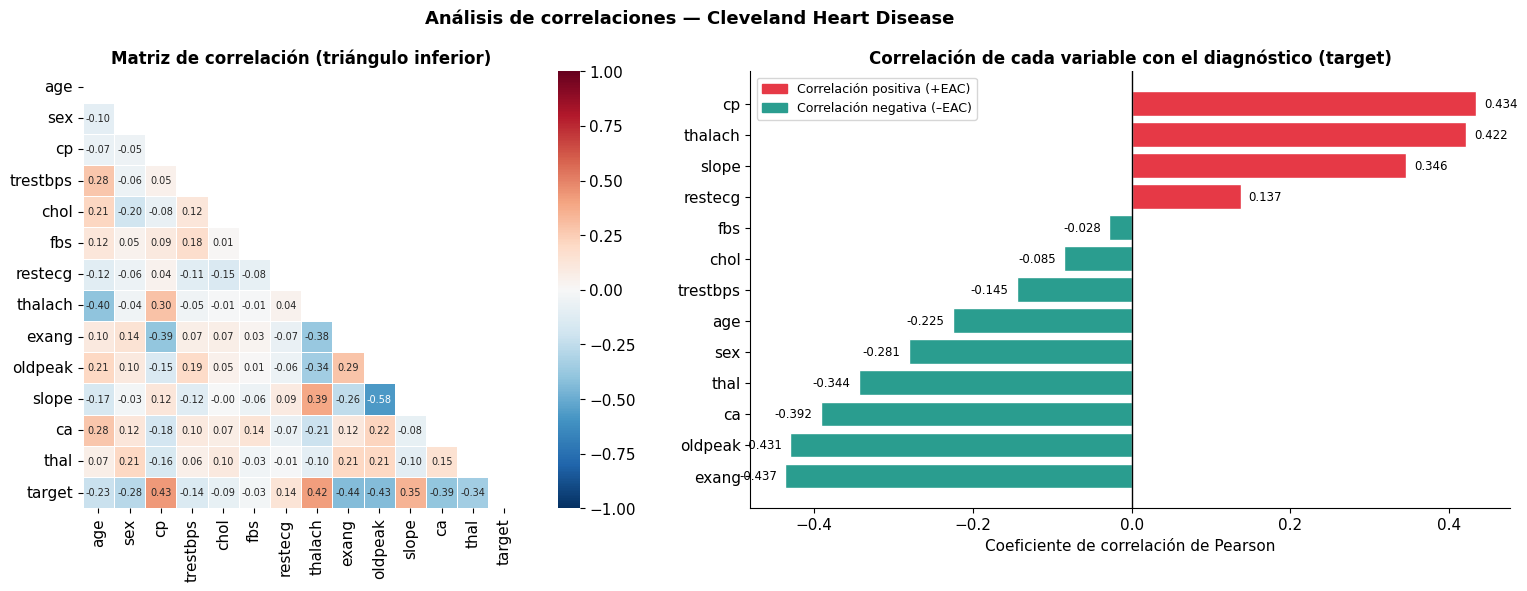

In [8]:
# ⛔ NO MODIFICAR — Mapa de correlaciones

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Análisis de correlaciones — Cleveland Heart Disease', fontsize=13, fontweight='bold')

# Heatmap de correlación completo
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 7})
axes[0].set_title('Matriz de correlación (triángulo inferior)', fontweight='bold')

# Correlación de cada variable con el target
corr_target = df.corr()['target'].drop('target').sort_values()
colores_corr = [C_POS if v > 0 else C_NEG for v in corr_target]
bars = axes[1].barh(corr_target.index, corr_target.values,
                    color=colores_corr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, corr_target.values):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha=ha, fontsize=8.5)
axes[1].set_title('Correlación de cada variable con el diagnóstico (target)',
                  fontweight='bold')
axes[1].set_xlabel('Coeficiente de correlación de Pearson')
axes[1].legend(handles=[
    mpatches.Patch(color=C_POS, label='Correlación positiva (+EAC)'),
    mpatches.Patch(color=C_NEG, label='Correlación negativa (–EAC)')
], fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 2.3 (4 pts)
#
# Tarea: Identifica y muestra en código:
#   a) Las 3 variables con MAYOR correlación positiva con el target
#   b) Las 3 variables con MAYOR correlación negativa con el target
#   c) ¿Hay algún par de variables con correlación > 0.7 entre sí
#      (excluyendo target)? Muéstralos.

# --- a) Top 3 correlación positiva con target ---


# --- b) Top 3 correlación negativa con target ---


# --- c) Pares de variables altamente correlacionadas ---


### 💬 Respuesta — Actividad 2.3 *(3 pts)*

*(Doble clic aquí para editar)*

**Describe en 3–5 oraciones los hallazgos clínicos más relevantes de tu EDA:**

- ¿Qué variables se asocian más fuertemente con la EAC y por qué tendría sentido clínicamente?
- ¿Encontraste algún hallazgo sorprendente o contraintuitivo?
- ¿Hay alguna variable que consideres redundante o poco informativa?

*(Escribe aquí tu análisis)*

---
## 🔧 Fase 3 — Preprocesamiento e Ingeniería de Características *(15 pts)*

Antes de entrenar cualquier modelo, los datos deben prepararse. Esta fase incluye:

1. **Tratamiento de valores faltantes** (si los hay)
2. **Encoding de variables categóricas** (convertir texto/categorías en números)
3. **Escalado de variables numéricas** (normalizar rangos)
4. **Ingeniería de características** (crear nuevas variables útiles)
5. **Separación train/test reproducible**

### Actividad 3.1 — Preprocesamiento base *(5 pts)*

In [10]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 3.1 (5 pts)
#
# Tarea: Construye un DataFrame preprocesado 'df_prep' con:
#
#   a) Copia del dataframe original (df.copy())
#   b) Convierte las variables categóricas ordinales a tipo
#      categórico con pd.Categorical o pd.get_dummies:
#      - cp (tipo de dolor): 4 categorías
#      - restecg: 3 categorías
#      - slope: 3 categorías
#      - thal: 3 categorías
#   c) Verifica que no queden valores nulos
#   d) Imprime un resumen de la forma final y tipos de datos
#
# Pista: usa pd.get_dummies(df_prep, columns=['cp','restecg','slope','thal'], drop_first=True)
# O bien, deja las variables como numéricas ordinales si lo justificas clínicamente.

# --- a) Copia del DataFrame ---
df_prep = df.copy()

# --- b) Encoding / tratamiento de categóricas ---
# (Tu decisión y justificación aquí)


# --- c) Verificación de nulos ---


# --- d) Resumen final ---
print(f'\n📋 DataFrame preprocesado:')
print(f'   Forma: {df_prep.shape}')


📋 DataFrame preprocesado:
   Forma: (303, 14)


### Actividad 3.2 — Ingeniería de características *(7 pts)*

La ingeniería de características consiste en **crear nuevas variables** combinando las existentes para capturar relaciones más complejas que los algoritmos por sí solos podrían no detectar.

**Ejemplos clínicos relevantes para este dataset:**
- Relación edad-frecuencia cardíaca máxima (`thalach / age`)
- Riesgo combinado: paciente hombre + fumador + edad > 55
- Clasificación de presión arterial por categorías OMS

In [11]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 3.2 (7 pts)
#
# Tarea: Crea AL MENOS 3 nuevas características con justificación clínica.
# Para cada una:
#   - Escribe el nombre de la variable
#   - Explica en un comentario qué representa clínicamente
#   - Calcula su correlación con el target
#
# Luego muestra las correlaciones de las nuevas variables con el target
# en un gráfico de barras.

# Ejemplo (NO cuentes esto como una de las 3 requeridas):
# df_prep['fc_reserva'] = 220 - df_prep['age'] - df_prep['thalach']
# (Reserva cronotropa: diferencia entre FC máxima teórica y la alcanzada)

# --- Feature 1 ---
# Nombre: ...
# Justificación clínica: ...


# --- Feature 2 ---
# Nombre: ...
# Justificación clínica: ...


# --- Feature 3 ---
# Nombre: ...
# Justificación clínica: ...


# --- Correlación de nuevas features con target ---


print('\n✅ Nuevas características creadas.')


✅ Nuevas características creadas.


In [12]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 3.3 *(3 pts)*
#
# Tarea: Divide los datos en conjuntos de entrenamiento y prueba.
#
#   - test_size = 0.20 (20% para prueba)
#   - Usa random_state = SEED (definido arriba)
#   - Usa stratify=y para mantener la proporción de clases
#   - Imprime la forma de cada conjunto y la proporción de target
#
# IMPORTANTE: X debe incluir TODAS las variables excepto 'target'

# --- Separar features y target ---
X = df_prep.drop('target', axis=1)
y = df_prep['target']

# --- División train/test ---
# X_train, X_test, y_train, y_test = ...


# --- Resumen ---


---
## 🤖 Fase 4 — Modelado y Selección de Algoritmo *(25 pts)*

Esta es la fase central del taller. Construirás y compararás múltiples modelos de clasificación para encontrar el que mejor predice la presencia de EAC.

**Recuerda:** En medicina, el mejor modelo no es siempre el de mayor exactitud — es el que mejor equilibra sensibilidad, especificidad y costo clínico de los errores.

### Actividad 4.1 — Benchmarking de modelos *(10 pts)*

In [13]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 4.1 (10 pts)
#
# Tarea: Compara AL MENOS 5 algoritmos de clasificación usando
# validación cruzada estratificada (5-fold) sobre el conjunto de ENTRENAMIENTO.
#
# Para cada modelo:
#   - Usa un Pipeline con [StandardScaler, modelo]
#   - Evalúa: ROC-AUC, F1, Sensibilidad (recall), Especificidad
#   - Guarda resultados en un DataFrame 'resultados_cv'
#
# Modelos sugeridos (puedes agregar más):
#   - LogisticRegression
#   - DecisionTreeClassifier
#   - RandomForestClassifier
#   - GradientBoostingClassifier
#   - KNeighborsClassifier
#   - SVC(probability=True)
#   - GaussianNB
#
# Al final: imprime la tabla de resultados ordenada por ROC-AUC
# y crea un gráfico de barras comparando los modelos.

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Define tus modelos aquí:
modelos_a_comparar = {
    # 'Nombre': Pipeline([('sc', StandardScaler()), ('m', Algoritmo())])
}

# --- Loop de evaluación ---
resultados_cv = []

for nombre, pipeline_m in modelos_a_comparar.items():
    pass  # Reemplaza con tu código

# --- DataFrame de resultados ---
# df_resultados = pd.DataFrame(resultados_cv).sort_values('ROC_AUC', ascending=False)

# --- Visualización comparativa ---


### Actividad 4.2 — Selección y optimización del modelo *(15 pts)*

In [14]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 4.2 (15 pts)
#
# Tarea: Selecciona el MEJOR modelo del benchmarking y optimiza
# sus hiperparámetros usando GridSearchCV.
#
# Pasos:
#   1. Justifica en comentarios por qué eliges ese modelo
#   2. Define una grilla de hiperparámetros (al menos 3 parámetros, 2+ valores c/u)
#   3. Ejecuta GridSearchCV con cv=cv_strat, scoring='roc_auc'
#   4. Imprime los mejores hiperparámetros encontrados
#   5. Entrena el modelo óptimo sobre TODO X_train
#   6. Guarda como 'modelo_final' (se usará en la Fase 5)
#
# Ejemplo de grilla para RandomForest:
# param_grid = {
#     'm__n_estimators': [100, 200, 300],
#     'm__max_depth': [3, 5, 7, None],
#     'm__min_samples_leaf': [1, 3, 5]
# }

# --- 1. Justificación de la elección ---
# (Escribe tu justificación aquí como comentario)


# --- 2. Definir grilla de hiperparámetros ---
param_grid = {
    # Tu grilla aquí
}

# --- 3. GridSearchCV ---


# --- 4. Mejores hiperparámetros ---


# --- 5. Entrenar modelo_final sobre todo X_train ---
modelo_final = None  # Reemplaza con tu modelo entrenado


print('✅ Modelo final entrenado y listo para evaluación.')

✅ Modelo final entrenado y listo para evaluación.


---
## 📊 Fase 5 — Evaluación Clínica del Modelo *(15 pts)*

Esta es la prueba de fuego. Ahora evaluarás tu modelo en el conjunto de TEST — datos que el modelo **nunca vio** durante el entrenamiento ni la optimización.

Un buen reporte clínico incluye:
- Sensibilidad y especificidad (métricas clínicas primarias)
- Curva ROC con área bajo la curva (AUC)
- Matriz de confusión anotada
- Número exacto de Falsos Negativos (pacientes con EAC no detectados)

### Actividad 5.1 — Evaluación en test set *(8 pts)*

In [15]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 5.1 (8 pts)
#
# Tarea: Evalúa modelo_final en X_test / y_test.
#
#   a) Genera predicciones (y_pred) y probabilidades (y_prob)
#   b) Calcula y muestra en pantalla:
#       - Exactitud (accuracy)
#       - Sensibilidad (recall para clase 1)
#       - Especificidad (recall para clase 0)
#       - Precisión (PPV)
#       - F1-Score
#       - ROC-AUC
#       - Número absoluto de Falsos Negativos
#   c) Imprime el reporte completo con classification_report

# --- a) Predicciones ---


# --- b) Métricas clínicas ---


# --- c) Reporte completo ---


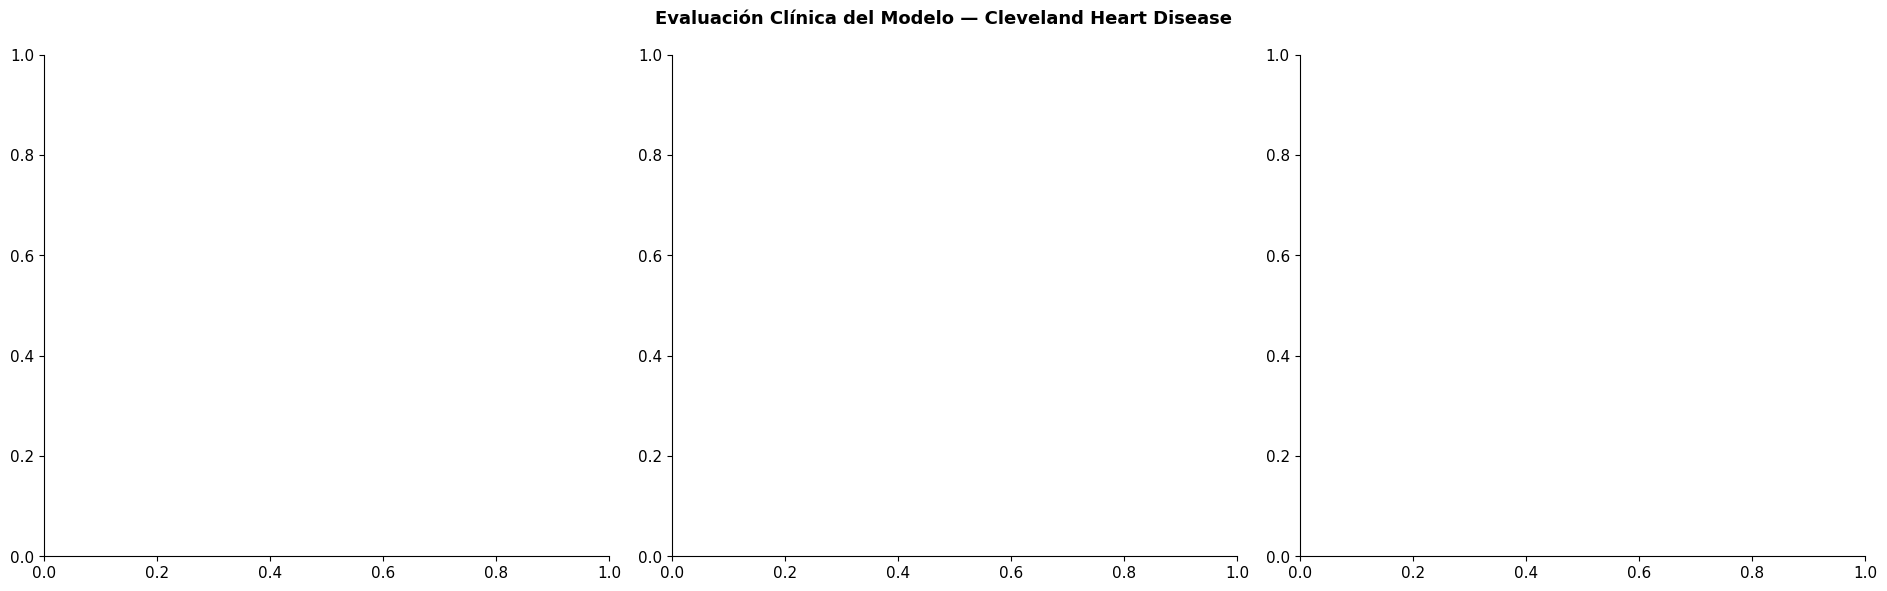

In [16]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 5.2 (7 pts)
#
# Tarea: Crea UN figura con 3 subplots:
#
#   Subplot 1 (izq): Curva ROC
#     - Dibuja la curva ROC con el área sombreada
#     - Marca el punto de umbral óptimo (máx Youden J = Sens + Esp - 1)
#     - Incluye la línea diagonal de referencia (azar)
#     - Etiqueta con el valor de AUC
#
#   Subplot 2 (centro): Matriz de confusión
#     - Usa ConfusionMatrixDisplay o sns.heatmap
#     - Etiquetas en español: 'Sin EAC', 'Con EAC'
#     - Anota: TP, TN, FP, FN
#
#   Subplot 3 (der): Curva de aprendizaje
#     - Muestra cómo mejora el modelo con más datos de entrenamiento
#     - Usa learning_curve() con scoring='roc_auc'
#     - Incluye bandas de ±1 desviación estándar

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle(f'Evaluación Clínica del Modelo — Cleveland Heart Disease',
             fontsize=13, fontweight='bold')

# --- Subplot 1: Curva ROC ---


# --- Subplot 2: Matriz de Confusión ---


# --- Subplot 3: Curva de Aprendizaje ---


plt.tight_layout()
plt.show()

### 💬 Interpretación clínica del modelo *(incluida en 5.1)*

*(Doble clic para editar)*

**Responde:**

1. ¿Tu modelo alcanzó la sensibilidad objetivo (>80%)? Si no, ¿qué estrategia aplicarías para mejorarla?
2. ¿Cuántos pacientes con EAC quedaron sin detectar (Falsos Negativos)? ¿Qué consecuencia clínica tiene esto?
3. ¿Es el rendimiento del modelo en TEST similar al de la validación cruzada? ¿Hay evidencia de sobreajuste?
4. ¿Considerarías este modelo apto para uso clínico real? Argumenta tu respuesta.

*(Escribe aquí tu interpretación)*

---
## 💡 Fase 6 — Interpretabilidad y Explicabilidad *(10 pts)*

Un modelo que funciona pero que nadie entiende difícilmente será adoptado en la clínica. La **interpretabilidad** permite a los médicos confiar en el modelo y detectar si está aprendiendo por razones equivocadas.

### Dos niveles de interpretabilidad

| Nivel | Pregunta que responde | Herramientas |
|-------|----------------------|-------------|
| **Global** | ¿Qué variables importan más para el modelo en general? | Feature importance, coeficientes |
| **Local** | ¿Por qué el modelo tomó ESA decisión para ESTE paciente? | SHAP values, LIME |

### Actividad 6.1 — Importancia global de variables *(5 pts)*

In [17]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 6.1 (5 pts)
#
# Tarea: Visualiza la importancia global de las variables.
#
#   Opción A (si tu modelo es RandomForest/GBM):
#     - Extrae feature_importances_ del estimador en el pipeline
#     - Crea un gráfico horizontal de barras ordenado de mayor a menor
#     - Colorea diferente las 5 más importantes
#
#   Opción B (si tu modelo es Regresión Logística):
#     - Extrae los coeficientes del modelo
#     - Crea un gráfico de barras con valores positivos (riesgo) y negativos (protector)
#
#   En ambos casos: añade un cuadro de texto en el gráfico con la
#   top 3 variable más importante y su valor

# --- Extraer importancias según tipo de modelo ---


# --- Gráfico ---


# --- Comparación con hipótesis inicial (Actividad 1.1) ---
print('\n💬 ¿La variable que predijiste en la Actividad 1.1 está entre las más importantes?')
print('   (Responde aquí comparando con tu respuesta inicial)')


💬 ¿La variable que predijiste en la Actividad 1.1 está entre las más importantes?
   (Responde aquí comparando con tu respuesta inicial)


### Actividad 6.2 — Explicación local: el caso del paciente *(5 pts)*

In [18]:
# ✏️ TU CÓDIGO AQUÍ — Actividad 6.2 (5 pts)
#
# Tarea: Elige UN paciente del test set y explica la predicción del modelo.
#
#   Paso 1: Elige un Falso Negativo (si hay) o cualquier paciente interesante
#   Paso 2: Muestra sus valores clínicos en una tabla formateada
#   Paso 3: Muestra la predicción del modelo y su probabilidad
#   Paso 4: Crea un gráfico de 'waterfall manual':
#     - Para cada variable, muestra su valor vs. la media del dataset
#     - Colorea en rojo si el valor aumenta el riesgo, verde si lo disminuye
#     - (Esto es una aproximación al concepto SHAP sin instalar bibliotecas extra)
#   Paso 5: Escribe una 'nota clínica' en formato Markdown que explique
#     la predicción como lo haría un médico leyendo el informe de la IA

# --- Paso 1: Selección del paciente ---
# Elige el índice de un paciente del test set
IDX_PACIENTE = 0  # Cambia este número

# --- Paso 2: Datos del paciente ---


# --- Paso 3: Predicción del modelo ---


# --- Paso 4: Perfil de riesgo visual ---


# --- Paso 5: Nota clínica en código ---
print('📋 NOTA CLÍNICA GENERADA POR EL MODELO DE IA')
print('=' * 55)
# (Imprime aquí la nota clínica con f-strings)

📋 NOTA CLÍNICA GENERADA POR EL MODELO DE IA


### 💬 Nota Clínica — Paciente Seleccionado *(incluida en 6.2)*

*(Doble clic para editar — escribe la nota clínica interpretando los resultados del modelo)*

**Nota Clínica — Reporte de IA**

**Paciente:** [descripción demográfica básica, sin datos identificables]  
**Evaluación:** Tamizaje de Enfermedad Arterial Coronaria  
**Modelo utilizado:** [nombre de tu modelo]  

**Hallazgos del perfil clínico:**
*(Escribe aquí)*

**Predicción del modelo:** [ ] Con EAC / [ ] Sin EAC  
**Probabilidad estimada:** ____%

**Principales factores que contribuyeron a esta predicción:**
*(Escribe aquí)*

**Recomendación:** *(lo que el modelo sugeriría como siguiente paso clínico)*

⚠️ *Este informe es generado por un sistema de IA con fines de apoyo diagnóstico. No reemplaza el juicio clínico del médico tratante.*

---
## 📝 Fase 7 — Informe Científico y Conclusiones *(5 pts)*

La ciencia que no se comunica no existe. En esta fase, redactarás un mini-informe científico estructurado sobre tu análisis.

Un buen informe de IA biomédica sigue la estructura **IMRD** (Introducción, Métodos, Resultados, Discusión).

### Instrucciones

Completa la celda Markdown de abajo con tu informe. Extensión: **400–600 palabras**.

**Criterios de evaluación:**
- ✅ Pregunta de investigación claramente formulada
- ✅ Métodos descritos con suficiente detalle para reproducir el estudio
- ✅ Resultados numéricos reportados (métricas específicas)
- ✅ Limitaciones del estudio reconocidas honestamente
- ✅ Lenguaje científico preciso pero comprensible
- ✅ Conclusión vinculada a la pregunta de investigación inicial

## 📄 Informe Científico

**Título:** *(Escribe un título descriptivo para tu análisis)*

**Autores:** *(Nombres del equipo)*

**Fecha:** *(Fecha de entrega)*

---

### Introducción

*(Presenta el problema clínico, su relevancia epidemiológica y la pregunta de investigación. 80–100 palabras.)*

---

### Métodos

**Datos:** *(Describe el dataset: origen, N de pacientes, variables, año de recolección)*

**Preprocesamiento:** *(¿Qué hiciste con los datos antes de modelar?)*

**Ingeniería de características:** *(¿Qué nuevas variables creaste y por qué?)*

**Modelos evaluados:** *(Lista los algoritmos comparados)*

**Selección y optimización:** *(¿Cómo elegiste el modelo final? ¿Qué hiperparámetros optimizaste?)*

**Evaluación:** *(¿Qué métricas usaste y por qué son apropiadas para este contexto?)*

---

### Resultados

*(Reporta los resultados numéricos clave. Usa una tabla si es útil.)*

| Métrica | Valor (test set) |
|---------|------------------|
| ROC-AUC | |
| Sensibilidad | |
| Especificidad | |
| F1-Score | |
| Falsos Negativos | |

**Variables más importantes:** *(Lista las 3 principales y su relevancia clínica)*

---

### Discusión

*(Interpreta tus resultados. ¿Alcanzaste el objetivo de sensibilidad >80%? ¿Por qué tu modelo funciona bien/mal? Compara con la literatura si puedes. 100–150 palabras.)*

**Limitaciones:**
- *(Limitación 1)*
- *(Limitación 2)*
- *(Limitación 3)*

---

### Conclusión

*(Responde la pregunta de investigación. ¿Es posible predecir EAC con alta sensibilidad? ¿Está el modelo listo para uso clínico? ¿Qué trabajo futuro se necesitaría? 60–80 palabras.)*

---

### Declaración ética

*(2–3 oraciones sobre las implicaciones éticas del uso de este modelo en la práctica clínica real)*

---
## 🌟 BONUS — Desafío Avanzado *(+10 pts, opcional)*

Completa **al menos 2** de los siguientes desafíos avanzados para obtener puntos extra.

| # | Desafío | Pts |
|---|---------|-----|
| B1 | **Ensemble personalizado** — Construye un VotingClassifier con tus 3 mejores modelos. Compara su rendimiento con el modelo individual. | +3 |
| B2 | **Análisis de umbral** — Genera una curva de Sensibilidad vs. Especificidad en función del umbral de decisión (0.1–0.9). Identifica el umbral que maximiza la sensibilidad manteniendo especificidad >60%. | +3 |
| B3 | **Segmentación de subgrupos** — Evalúa si el modelo funciona igual en hombres vs. mujeres (o jóvenes <50 vs. mayores ≥50). Detecta y discute posible sesgo algorítmico. | +2 |
| B4 | **PCA + Visualización** — Aplica PCA sobre las variables numéricas y visualiza los dos primeros componentes coloreando por diagnóstico. Interpreta los loadings. | +2 |

---

In [19]:
# ✏️ BONUS B1 — Ensemble personalizado (+3 pts)
#
# Construye un VotingClassifier con tus 3 mejores modelos.
# Compara AUC, Sensibilidad y Especificidad vs. tu modelo_final.

# Tu código aquí


In [20]:
# ✏️ BONUS B2 — Análisis de umbral de decisión (+3 pts)
#
# Genera la curva Sensibilidad vs. Especificidad en función del umbral.
# Identifica el umbral clínicamente óptimo para este caso.

# Tu código aquí


In [21]:
# ✏️ BONUS B3 — Análisis de sesgo por subgrupo (+2 pts)
#
# Evalúa el rendimiento del modelo en hombres vs. mujeres
# (o en el subgrupo de tu elección). Discute si hay sesgo.

# Tu código aquí


In [22]:
# ✏️ BONUS B4 — PCA + Visualización (+2 pts)
#
# Aplica PCA sobre las variables numéricas y visualiza
# los 2 primeros componentes coloreados por diagnóstico.
# Incluye el scree plot y la interpretación de loadings.

# Tu código aquí


---
## ✅ Lista de verificación final

Antes de entregar, confirma que completaste todo:

**Fase 1 — Comprensión clínica**
- [ ] Datos del equipo completados en la portada
- [ ] Actividad 1.1: 4 preguntas respondidas

**Fase 2 — EDA**
- [ ] Actividad 2.1: 5 estadísticos calculados
- [ ] Actividad 2.2: gráfico 2×2 de variables categóricas
- [ ] Actividad 2.3: correlaciones + análisis en texto

**Fase 3 — Preprocesamiento**
- [ ] Actividad 3.1: df_prep construido
- [ ] Actividad 3.2: ≥3 nuevas características con justificación
- [ ] Actividad 3.3: X_train, X_test, y_train, y_test separados

**Fase 4 — Modelado**
- [ ] Actividad 4.1: ≥5 modelos comparados con tabla y gráfico
- [ ] Actividad 4.2: GridSearchCV + modelo_final entrenado

**Fase 5 — Evaluación clínica**
- [ ] Actividad 5.1: métricas en test set + n° FN
- [ ] Actividad 5.2: ROC + Matriz Confusión + Curva de Aprendizaje
- [ ] Interpretación clínica en Markdown

**Fase 6 — Interpretabilidad**
- [ ] Actividad 6.1: importancia de variables con gráfico
- [ ] Actividad 6.2: explicación de paciente + nota clínica

**Fase 7 — Informe**
- [ ] Informe completo (Intro + Métodos + Resultados + Discusión + Conclusión + Ética)

**BONUS** *(opcional)*
- [ ] B1 Ensemble, [ ] B2 Umbral, [ ] B3 Subgrupos, [ ] B4 PCA

---

## 🎓 Rúbrica de evaluación

| Criterio | Insuficiente (0–59%) | Suficiente (60–79%) | Bueno (80–89%) | Excelente (90–100%) |
|----------|---------------------|--------------------|-----------------|-----------------------|
| **Comprensión clínica** | Sin relación con el contexto | Definiciones básicas | Relaciona variables con fisiopatología | Razonamiento clínico profundo y bien justificado |
| **EDA** | Solo estadísticas básicas | Distribuciones sin análisis | Gráficos comentados | Hallazgos clínicamente relevantes identificados |
| **Modelado** | Un solo modelo sin comparar | 2–3 modelos, sin optimización | ≥5 modelos, optimización básica | Pipeline robusto, GridSearch justificado, CV estratificado |
| **Evaluación** | Solo exactitud | AUC + 1 métrica más | AUC + Sens + Esp + FN | Interpretación clínica completa, umbral analizado |
| **Interpretabilidad** | Sin análisis de variables | Lista de importancias | Gráfico + comparación con hipótesis | Explicación por paciente + nota clínica coherente |
| **Informe** | Incompleto o sin estructura | Estructura IMRD básica | Resultados numéricos + limitaciones | Redacción científica, comparación con literatura |
| **Código** | No ejecuta o sin comentarios | Ejecuta con errores menores | Limpio y comentado | Reproducible, organizado, documentado profesionalmente |

---

### 💬 Reflexión final del equipo

*(Doble clic para editar — Responde en 3–4 oraciones)*

**¿Qué fue lo más desafiante de este taller?**

*(Escribe aquí)*

**¿Qué habilidad o concepto del curso te pareció más valioso para el análisis?**

*(Escribe aquí)*

**Si pudieras continuar este proyecto, ¿cuál sería el siguiente paso?**

*(Escribe aquí)*

---

### 📚 Referencias y recursos utilizados

*(Lista aquí los artículos, libros o recursos que consultaste durante el taller)*

1. Detrano, R. et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304–310.
2. UCI Machine Learning Repository — Heart Disease Dataset: https://archive.ics.uci.edu/dataset/45/heart+disease
3. *(Añade tus referencias aquí)*

---

*Taller Final — Análisis de Datos con Inteligencia Artificial*  
*Curso de Introducción a la IA | Septiembre 2026*  
*"El mejor modelo de IA es aquel que el clínico entiende, confía y puede cuestionar."*